In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('physrev_noticks.mplstyle')
plt.rcParams.update({"figure.figsize": [3.25*8, 1.01]})
plt.rcParams['figure.dpi'] = "300"

In [2]:
stat_names = ["AC", "CS", "SG", "VD"]
model_names = ["SubATTM", "SubCTRW", "SubFBM", "SubSBM", "SupFBM", "SupLW", "SupSBM", "STDBM"]

In [3]:
total_l2_mean_tot = {}
total_l2_std_tot = {}

original_stats = {}
for save_tag_index in range(5):
    original_stats[save_tag_index] = {}
    for index, index_name in enumerate(["AC", "CS", "SG", "VD"]):
        index += 1
        concat_list = [
            np.load(f"./analysis_results//statistical_relevance/features/{save_tag_index}_s{index}.npy")
        ]
        original_stats[save_tag_index][index_name] = np.concatenate(concat_list)


for stat_name in stat_names:
    total_l2_mean_tot[stat_name] = {}
    total_l2_std_tot[stat_name] = {}

    for compare_stat_name in stat_names:
        l2_norm_tot = []
        for model_index, model_name in enumerate(model_names):

            for save_tag_index in range(5):
            
                original_stat = original_stats[save_tag_index]
                injected_stat = dict(np.load(f"./analysis_results/feature_ablation/injected_dict/{save_tag_index}/{stat_name}_injected_total_stat.npy", allow_pickle=True).item())
                scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])


                original_stat_scaled = scaling_function(original_stat[compare_stat_name][model_index*10000:(model_index+1)*10000])
                injected_stat_scaled = scaling_function(injected_stat[compare_stat_name][model_index*10000:(model_index+1)*10000])

                l2_norm = np.mean(np.sqrt((original_stat_scaled-injected_stat_scaled)**2), axis=-1)
                l2_norm_tot.extend(l2_norm[~np.isnan(l2_norm)])

        total_l2_mean_tot[stat_name][compare_stat_name] = np.mean(l2_norm_tot)
        total_l2_std_tot[stat_name][compare_stat_name] = np.std(l2_norm_tot)


/tmp/ipykernel_1903004/447663436.py:27: RuntimeWarning: invalid value encountered in subtract
  scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])
/tmp/ipykernel_1903004/447663436.py:27: RuntimeWarning: invalid value encountered in divide
  scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])


In [4]:
total_l2_mean_inverse_tot = {}
total_l2_std_inverse_tot = {}

original_stats = {}
for save_tag_index in range(5):
    original_stats[save_tag_index] = {}
    for index, index_name in enumerate(["AC", "CS", "SG", "VD"]):
        index += 1
        concat_list = [
            np.load(f"./analysis_results//statistical_relevance/features/{save_tag_index}_s{index}.npy")
        ]
        original_stats[save_tag_index][index_name] = np.concatenate(concat_list)


for stat_name in stat_names:
    total_l2_mean_inverse_tot[stat_name] = {}
    total_l2_std_inverse_tot[stat_name] = {}

    for compare_stat_name in stat_names:
        l2_norm_tot = []
        for model_index, model_name in enumerate(model_names):

            for save_tag_index in range(5):
            
                original_stat = original_stats[save_tag_index]
                injected_stat = dict(np.load(f"./analysis_results/feature_ablation/injected_dict/{save_tag_index}/{stat_name}_injected_total_stat_inverse.npy", allow_pickle=True).item())
                scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])


                original_stat_scaled = scaling_function(original_stat[compare_stat_name][model_index*10000:(model_index+1)*10000])
                injected_stat_scaled = scaling_function(injected_stat[compare_stat_name][model_index*10000:(model_index+1)*10000])

                l2_norm = np.mean(np.sqrt((original_stat_scaled-injected_stat_scaled)**2), axis=-1)
                l2_norm_tot.extend(l2_norm[~np.isnan(l2_norm)])

            total_l2_mean_inverse_tot[stat_name][compare_stat_name] = np.mean(l2_norm_tot)
            total_l2_std_inverse_tot[stat_name][compare_stat_name] = np.std(l2_norm_tot)


/tmp/ipykernel_1903004/2190807823.py:27: RuntimeWarning: invalid value encountered in subtract
  scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])
/tmp/ipykernel_1903004/2190807823.py:27: RuntimeWarning: invalid value encountered in divide
  scaling_function = lambda x: (x-np.min(x, axis=-1)[:, np.newaxis])/(np.max(x, axis=-1)[:, np.newaxis]-np.min(x, axis=-1)[:, np.newaxis])


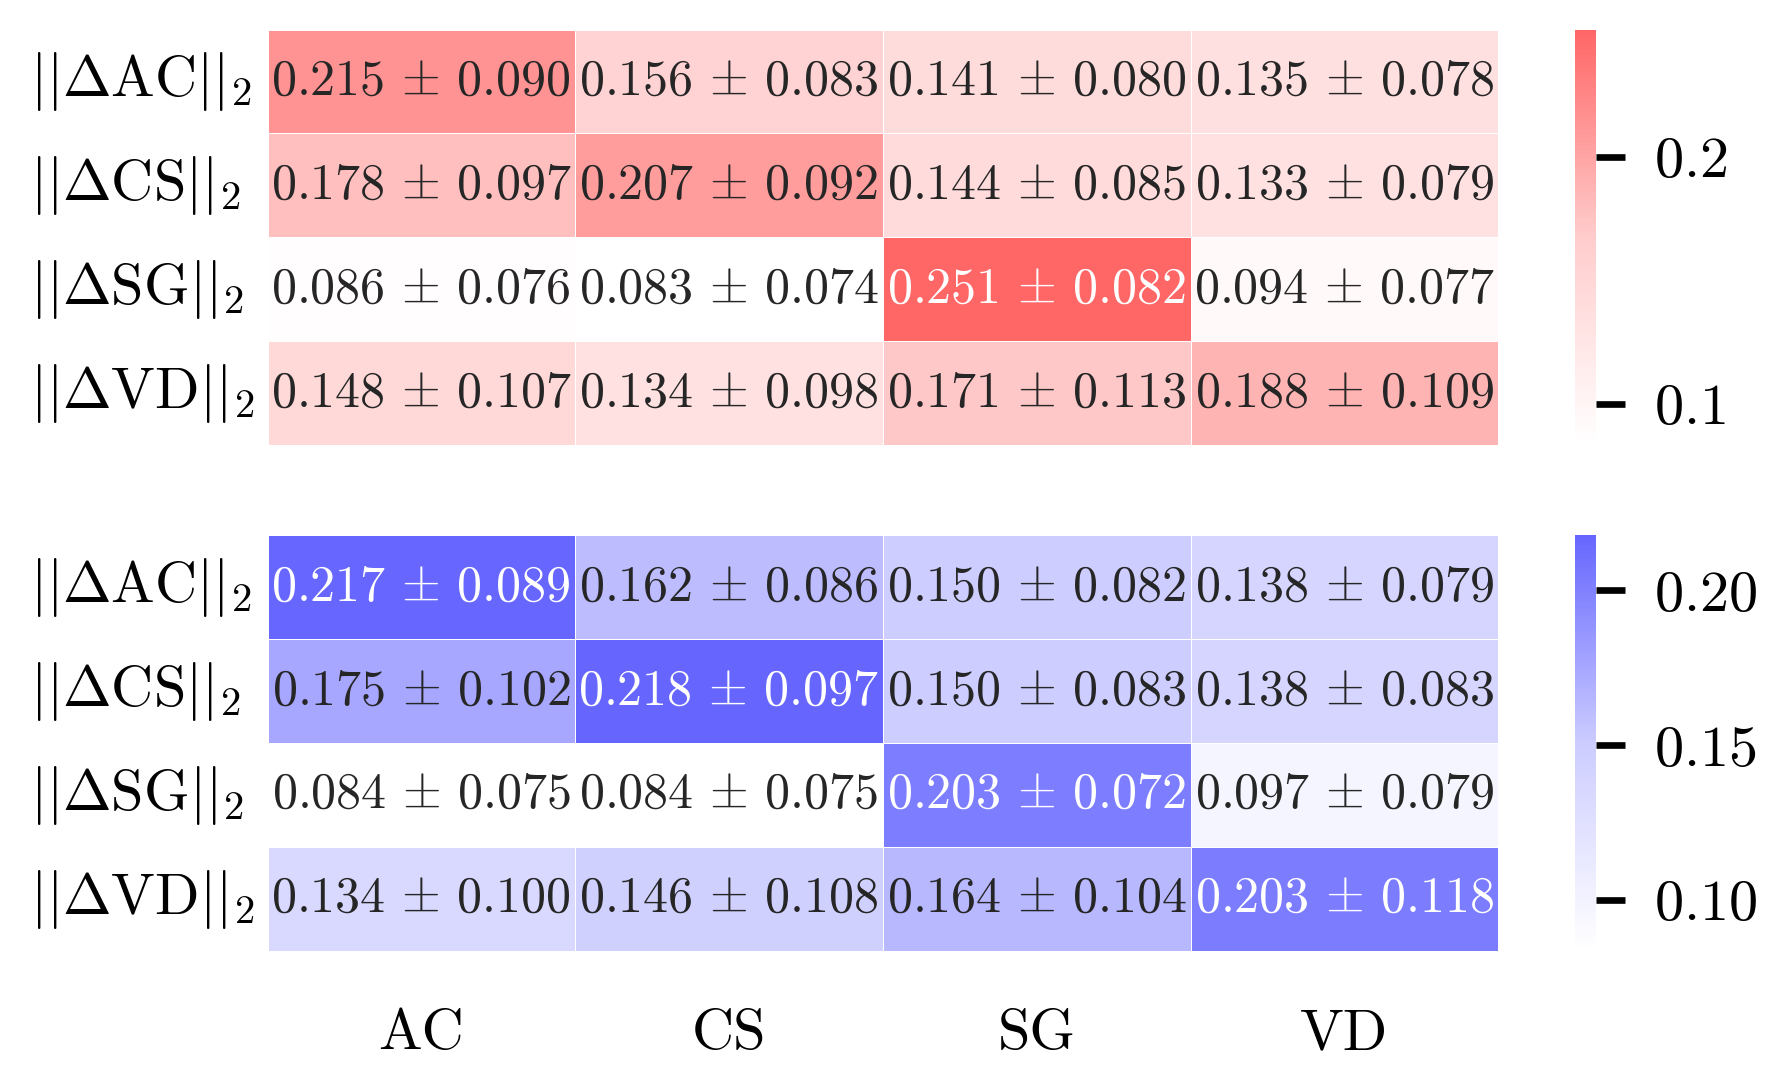

In [5]:
# Creating data for the first heatmap
from matplotlib.colors import LinearSegmentedColormap

df1 = pd.DataFrame(index=["AC", "CS", "SG", "VD"], columns=["AC", "CS", "SG", "VD"])
df_annot1 = pd.DataFrame(index=["AC", "CS", "SG", "VD"], columns=["AC", "CS", "SG", "VD"])

for stat_name_1 in stat_names:
    for stat_name_2 in stat_names:
        data_val = total_l2_mean_tot[stat_name_1][stat_name_2]
        sigma_val = total_l2_std_tot[stat_name_1][stat_name_2]
        df1.loc[stat_name_1, stat_name_2] = data_val # loc["row", "column"]
        df_annot1.loc[stat_name_1, stat_name_2] = rf"{data_val:.3f} $\pm$ {sigma_val:.3f}"

df1 = df1.apply(pd.to_numeric, errors='coerce')
colors1 = [(1, 1, 1), (1, 0.8, 0.8), (1, 0.4, 0.4)]
vmin1 = df1.min().min()
vmax1 = df1.max().max()
cmap1 = LinearSegmentedColormap.from_list('', colors1)

# Creating data for the second heatmap
df2 = pd.DataFrame(index=["AC", "CS", "SG", "VD"], columns=["AC", "CS", "SG", "VD"])
df_annot2 = pd.DataFrame(index=["AC", "CS", "SG", "VD"], columns=["AC", "CS", "SG", "VD"])

for stat_name_1 in stat_names:
    for stat_name_2 in stat_names:
        data_val = total_l2_mean_inverse_tot[stat_name_1][stat_name_2]
        sigma_val = total_l2_std_inverse_tot[stat_name_1][stat_name_2]
        df2.loc[stat_name_1, stat_name_2] = data_val
        df_annot2.loc[stat_name_1, stat_name_2] = rf"{data_val:.3f} $\pm$ {sigma_val:.3f}"

df2 = df2.apply(pd.to_numeric, errors='coerce')
colors2 = [(1, 1, 1), (0.8, 0.8, 1), (0.4, 0.4, 1)]
vmin2 = df2.min().min()
vmax2 = df2.max().max()
cmap2 = LinearSegmentedColormap.from_list('', colors2)

# Plotting the heatmaps
fig, axes = plt.subplots(2, 1, figsize=(3.26, 2.02), sharex=True)  # Adjust height to fit both heatmaps

# First heatmap
sns.heatmap(
    df1.T, annot=df_annot1.T, cmap=cmap1, vmin=vmin1, vmax=vmax1, linewidths=0.1,
    linecolor='white', fmt='', cbar=True, annot_kws={"size": 6}, ax=axes[0]
)
axes[0].set_yticklabels(
    [r"$||\Delta\text{AC}||_2$", r"$||\Delta\text{CS}||_2$", r"$||\Delta\text{SG}||_2$", r"$||\Delta\text{VD}||_2$"],
    rotation="horizontal", horizontalalignment="left"
)
axes[0].tick_params(axis='y', pad=25)

# Second heatmap
sns.heatmap(
    df2.T, annot=df_annot2.T, cmap=cmap2, vmin=vmin2, vmax=vmax2, linewidths=0.1,
    linecolor='white', fmt='', cbar=True, annot_kws={"size": 6}, ax=axes[1]
)
axes[1].set_yticklabels(
    [r"$||\Delta\text{AC}||_2$", r"$||\Delta\text{CS}||_2$", r"$||\Delta\text{SG}||_2$", r"$||\Delta\text{VD}||_2$"],
    rotation="horizontal", horizontalalignment="left"
)
axes[1].tick_params(axis='y', pad=25)

# Save and show the figure
plt.tight_layout()
plt.savefig("./figures/independence_check_combined_total.pdf")
plt.show()

In [6]:
"DONE"

'DONE'